In [1]:

import pandas as pd
import numpy as np
import warnings, re
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

#Data Loading

DATA_PATH = "fobhav_noisy.csv"
SYMBOLS = ["NIFTY", "BANKNIFTY"]
CHUNK_SIZE = 500_000
def load_and_filter(path, symbols, chunksize=CHUNK_SIZE):
    frames = []
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        mask = chunk["SYMBOL"].isin(symbols)
        if mask.any():
            frames.append(chunk.loc[mask])
    return pd.concat(frames, ignore_index=True)
print("▶ Loading data (chunked)...")
df = load_and_filter(DATA_PATH, SYMBOLS)
print(f"  Loaded {len(df):,} rows for {SYMBOLS}")

▶ Loading data (chunked)...
  Loaded 4,979,025 rows for ['NIFTY', 'BANKNIFTY']


In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4979025 entries, 0 to 4979024
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   INSTRUMENT  str    
 1   SYMBOL      str    
 2   EXPIRY_DT   str    
 3   STRIKE_PR   float64
 4   OPTION_TYP  str    
 5   OPEN        float64
 6   HIGH        float64
 7   LOW         float64
 8   CLOSE       float64
 9   SETTLE_PR   float64
 10  CONTRACTS   float64
 11  VAL_INLAKH  float64
 12  OPEN_INT    float64
 13  CHG_IN_OI   float64
 14  TIMESTAMP   str    
 15  Column_15   float64
dtypes: float64(11), str(5)
memory usage: 783.1 MB


,STRIKE_PR,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,Column_15
count,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,4.979025e+06,0.0
mean,1.259368e+04,9.665163e+01,1.040382e+02,9.210107e+01,1.105921e+03,1.283530e+03,3.049759e+03,1.916369e+04,7.411234e+04,2.101179e+03,NaN
std,1.618318e+04,2.383721e+03,2.407978e+03,2.272451e+03,2.943129e+03,3.290926e+03,7.116351e+04,4.856214e+05,9.924162e+06,1.023966e+06,NaN
min,-7.907301e+04,-1.328270e+04,-1.339722e+04,-1.262116e+04,-1.505194e+04,-1.549634e+04,-3.334565e+05,-2.397858e+06,-5.884656e+07,-8.779500e+06,NaN
25%,7.750000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+02,4.595000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,1.040000e+04,0.000000e+00,0.000000e+00,0.000000e+00,7.357500e+02,6.403000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
75%,1.660000e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.707600e+03,1.963150e+03,0.000000e+00,0.000000e+00,7.500000e+01,0.000000e+00,NaN
max,9.371066e+04,3.280135e+04,3.297420e+04,3.264000e+04,3.279890e+04,3.279890e+04,4.783402e+06,2.984563e+07,5.957327e+07,1.052092e+07,NaN


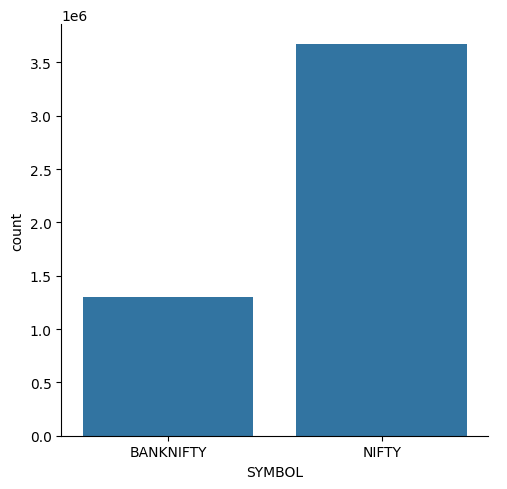

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.catplot(x='SYMBOL',data=df,kind='count')

<Axes: >

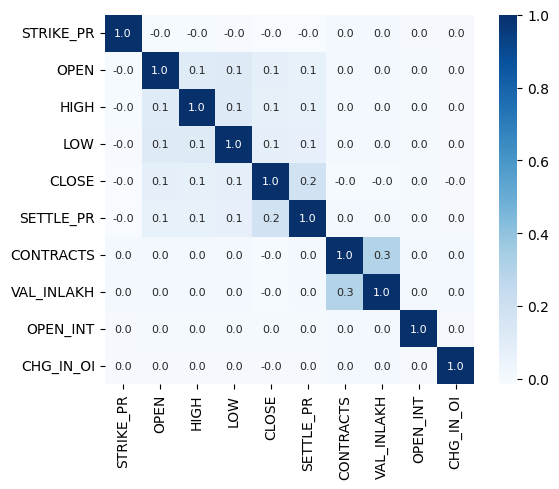

In [4]:
newdf=df[["STRIKE_PR","OPEN","HIGH","LOW","CLOSE","SETTLE_PR","CONTRACTS","VAL_INLAKH","OPEN_INT","CHG_IN_OI"]]
correlation=newdf.corr()

plt.Figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,annot=True,fmt='.1f',cmap='Blues',annot_kws={'size':8})

In [5]:
# 2. NOISE CLEANING

def clean_instrument(val):
    v = str(val).upper().strip().replace("_UNK", "")
    if "FUT" in v:
        return "FUTIDX"
    if any(k in v for k in ["OPT", "PST", "TSK", "OTP", "POT", "POS", "PTD"]):
        return "OPTIDX"
    return None
def clean_option_type(val):
    v = str(val).upper().strip().replace("_UNK", "")
    if v == "XX":
        return "XX"
    if v in ("CE", "EC"):
        return "CE"
    if v in ("PE", "EP"):
        return "PE"
    if v.startswith("C"):
        return "CE"
    if v.startswith("P"):
        return "PE"
    return None
def parse_timestamp(val):
    """Robust parser: handles _UNK suffix, lowercase, and rejects garbage."""
    v = str(val).strip()

    # Remove _UNK suffix

    v = re.sub(r'_UNK$', '', v, flags=re.IGNORECASE)

    # Try standard DD-MON-YYYY (case-insensitive)

    try:
        return pd.to_datetime(v, format="%d-%b-%Y")
    except Exception:
        pass
    # Try lowercase month
    try:
        return pd.to_datetime(v.upper(), format="%d-%b-%Y")
    except Exception:
        pass

    

    return pd.NaT
print("▶ Cleaning noisy columns...")
df["INSTRUMENT"] = df["INSTRUMENT"].map(clean_instrument)
df["OPTION_TYP"] = df["OPTION_TYP"].map(clean_option_type)
df["TIMESTAMP"]  = df["TIMESTAMP"].apply(parse_timestamp)
df.dropna(subset=["INSTRUMENT", "OPTION_TYP", "TIMESTAMP"], inplace=True)
num_cols = ["STRIKE_PR", "OPEN", "HIGH", "LOW", "CLOSE",
            "SETTLE_PR", "CONTRACTS", "VAL_INLAKH", "OPEN_INT", "CHG_IN_OI"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["OPEN_INT"] = df["OPEN_INT"].fillna(0)
df["CHG_IN_OI"] = df["CHG_IN_OI"].fillna(0)
df["CONTRACTS"] = df["CONTRACTS"].fillna(0)
df.dropna(subset=["CLOSE"], inplace=True)
df.drop(columns=["Column_15"], errors="ignore", inplace=True)
df.sort_values(["SYMBOL", "TIMESTAMP", "STRIKE_PR"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Clean rows: {len(df):,}")
print(f"  Instruments: {df['INSTRUMENT'].value_counts().to_dict()}")
print(f"  Option types: {df['OPTION_TYP'].value_counts().to_dict()}")
print(f"  Date range: {df['TIMESTAMP'].min()} → {df['TIMESTAMP'].max()}")


▶ Cleaning noisy columns...
  Clean rows: 4,910,355
  Instruments: {'OPTIDX': 4901459, 'FUTIDX': 8896}
  Option types: {'PE': 2452456, 'CE': 2449003, 'XX': 8896}
  Date range: 0214-03-12 00:00:00 → 2200-08-31 00:00:00


In [6]:

#  FEATURE ENGINEERING
def engineer_features(df):
    futures = df[df["OPTION_TYP"] == "XX"].copy()
    options = df[df["OPTION_TYP"].isin(["CE", "PE"])].copy()

    # Pre-build futures lookup dict for speed

    fut_lookup = {}
    for (sym, date), grp in futures.groupby(["SYMBOL", "TIMESTAMP"]):
        row = grp.iloc[0]
        fut_lookup[(sym, date)] = {
            "FUT_CLOSE": row["CLOSE"], "FUT_HIGH": row["HIGH"],
            "FUT_LOW": row["LOW"], "FUT_OI": row["OPEN_INT"],
            "FUT_OI_CHG": row["CHG_IN_OI"]
        }
    daily_agg = []
    for (sym, date), grp in options.groupby(["SYMBOL", "TIMESTAMP"]):
        calls = grp[grp["OPTION_TYP"] == "CE"]
        puts  = grp[grp["OPTION_TYP"] == "PE"]
        total_ce_oi = calls["OPEN_INT"].sum()
        total_pe_oi = puts["OPEN_INT"].sum()
        pcr_oi = total_pe_oi / max(total_ce_oi, 1)
        total_ce_vol = calls["CONTRACTS"].sum()
        total_pe_vol = puts["CONTRACTS"].sum()
        pcr_vol = total_pe_vol / max(total_ce_vol, 1)
        oi_threshold = grp["OPEN_INT"].quantile(0.90) if len(grp) > 1 else 0
        oi_clusters = grp[grp["OPEN_INT"] >= max(oi_threshold, 1)]
        max_ce_oi_strike = calls.loc[calls["OPEN_INT"].idxmax(), "STRIKE_PR"] if len(calls) > 0 else 0
        max_pe_oi_strike = puts.loc[puts["OPEN_INT"].idxmax(), "STRIKE_PR"]  if len(puts) > 0 else 0
        ce_oi_change = calls["CHG_IN_OI"].sum()
        pe_oi_change = puts["CHG_IN_OI"].sum()
        trapped_calls = calls[(calls["OPEN_INT"] > oi_threshold) & (calls["CHG_IN_OI"] < 0)]
        trapped_puts  = puts[(puts["OPEN_INT"] > oi_threshold) & (puts["CHG_IN_OI"] < 0)]
        liq_trap_score = (len(trapped_calls) + len(trapped_puts)) / max(len(oi_clusters), 1)
        squeeze_signal = calls[
            (calls["OPEN_INT"] > oi_threshold) &
            (calls["CHG_IN_OI"] < -calls["OPEN_INT"] * 0.05)
        ].shape[0]

        # Use futures if available, otherwise derive price from ATM options

        fl = fut_lookup.get((sym, date))
        if fl:
            fut_close, fut_high, fut_low = fl["FUT_CLOSE"], fl["FUT_HIGH"], fl["FUT_LOW"]
            fut_oi, fut_oi_chg = fl["FUT_OI"], fl["FUT_OI_CHG"]
        else:

            # Approximate underlying from weighted-avg of option closes

            fut_close = grp["CLOSE"].median()
            fut_high = grp["HIGH"].median()
            fut_low = grp["LOW"].median()
            fut_oi = grp["OPEN_INT"].sum()
            fut_oi_chg = grp["CHG_IN_OI"].sum()
        daily_agg.append({
            "SYMBOL": sym, "DATE": date,
            "FUT_CLOSE": fut_close, "FUT_HIGH": fut_high, "FUT_LOW": fut_low,
            "FUT_OI": fut_oi, "FUT_OI_CHG": fut_oi_chg,
            "PCR_OI": pcr_oi, "PCR_VOL": pcr_vol,
            "TOTAL_CE_OI": total_ce_oi, "TOTAL_PE_OI": total_pe_oi,
            "CE_OI_CHANGE": ce_oi_change, "PE_OI_CHANGE": pe_oi_change,
            "MAX_CE_OI_STRIKE": max_ce_oi_strike,
            "MAX_PE_OI_STRIKE": max_pe_oi_strike,
            "LIQ_TRAP_SCORE": liq_trap_score,
            "SQUEEZE_SIGNAL": squeeze_signal,
            "N_OI_CLUSTERS": len(oi_clusters),
            "TOTAL_CONTRACTS": grp["CONTRACTS"].sum(),
            "TOTAL_VALUE": grp["VAL_INLAKH"].sum(),
        })
    feat = pd.DataFrame(daily_agg)
    feat.sort_values(["SYMBOL", "DATE"], inplace=True)
    feat.reset_index(drop=True, inplace=True)
    print(f"  Daily aggregates: {len(feat)} rows")

    # Rolling features per symbol

    parts = []
    for sym in feat["SYMBOL"].unique():
        sub = feat[feat["SYMBOL"] == sym].copy()
        sub["RETURN_1D"] = sub["FUT_CLOSE"].pct_change()
        sub["VOLATILITY_5D"] = sub["RETURN_1D"].rolling(5, min_periods=2).std()
        sub["VOLATILITY_10D"] = sub["RETURN_1D"].rolling(10, min_periods=3).std()
        sub["PCR_OI_MA5"]  = sub["PCR_OI"].rolling(5, min_periods=2).mean()
        sub["PCR_OI_MA10"] = sub["PCR_OI"].rolling(10, min_periods=3).mean()
        sub["FUT_OI_MA5"] = sub["FUT_OI"].rolling(5, min_periods=2).mean()
        sub["CE_OI_CHG_MA5"] = sub["CE_OI_CHANGE"].rolling(5, min_periods=2).mean()
        sub["PE_OI_CHG_MA5"] = sub["PE_OI_CHANGE"].rolling(5, min_periods=2).mean()
        sub["PRICE_RANGE"] = (sub["FUT_HIGH"] - sub["FUT_LOW"]) / sub["FUT_CLOSE"].replace(0, np.nan)
        sub["TARGET"] = (sub["FUT_CLOSE"].shift(-1) > sub["FUT_CLOSE"]).astype(int)
        parts.append(sub)
    feat = pd.concat(parts, ignore_index=True)

    # drop rows where rolling couldn't compute (first few) and last row (no target)

    feat.dropna(subset=["RETURN_1D", "VOLATILITY_5D", "TARGET"], inplace=True)

    # Fill any remaining NaN with 0

    feat.fillna(0, inplace=True)
    feat.reset_index(drop=True, inplace=True)
    return feat
print("▶ Engineering features...")
features = engineer_features(df)
print(f"  Feature matrix: {features.shape}")
print(f"  Date range: {features['DATE'].min()} → {features['DATE'].max()}")
print(f"  Symbols: {features['SYMBOL'].value_counts().to_dict()}")
print(f"  Target distribution:\n{features['TARGET'].value_counts().to_string()}")


▶ Engineering features...
  Daily aggregates: 11194 rows
  Feature matrix: (11190, 30)
  Date range: 0214-03-14 00:00:00 → 2200-08-31 00:00:00
  Symbols: {'NIFTY': 6370, 'BANKNIFTY': 4820}
  Target distribution:
TARGET
1    5694
0    5496


In [7]:

# TEMPORAL FUSION TRANSFORMER (TFT)

FEATURE_COLS = [
    "PCR_OI", "PCR_VOL", "TOTAL_CE_OI", "TOTAL_PE_OI",
    "CE_OI_CHANGE", "PE_OI_CHANGE", "LIQ_TRAP_SCORE", "SQUEEZE_SIGNAL",
    "N_OI_CLUSTERS", "TOTAL_CONTRACTS", "TOTAL_VALUE",
    "FUT_OI", "FUT_OI_CHG", "PRICE_RANGE",
    "RETURN_1D", "VOLATILITY_5D", "VOLATILITY_10D",
    "PCR_OI_MA5", "PCR_OI_MA10", "FUT_OI_MA5",
    "CE_OI_CHG_MA5", "PE_OI_CHG_MA5",
]
SEQ_LEN = 15
HIDDEN  = 128
HEADS   = 8
LAYERS  = 2
EPOCHS  = 100
BATCH   = 64
LR      = 1e-3
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X, self.y, self.seq_len = X, y, seq_len
    def __len__(self):
        return max(0, len(self.X) - self.seq_len)
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx : idx + self.seq_len], dtype=torch.float32),
            torch.tensor(self.y[idx + self.seq_len - 1], dtype=torch.float32),
        )
class GatedResidualNetwork(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_in, d_hidden)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(d_hidden, d_out)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(d_out, d_out)
        self.sigmoid = nn.Sigmoid()
        self.layernorm = nn.LayerNorm(d_out)
        self.skip = nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity()
    def forward(self, x):
        residual = self.skip(x)
        h = self.dropout(self.elu(self.fc1(x)))
        h = self.fc2(h)
        gate = self.sigmoid(self.gate(h))
        return self.layernorm(residual + gate * h)
class VariableSelectionNetwork(nn.Module):
    def __init__(self, n_features, d_hidden, dropout=0.1):
        super().__init__()
        self.grns = nn.ModuleList([
            GatedResidualNetwork(1, d_hidden, d_hidden, dropout)
            for _ in range(n_features)
        ])
        self.grn_weights = GatedResidualNetwork(n_features, d_hidden, n_features, dropout)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):
        weights = self.softmax(self.grn_weights(x))
        processed = torch.stack(
            [grn(x[:, :, i:i+1]) for i, grn in enumerate(self.grns)],
            dim=-1
        )
        weights_expanded = weights.unsqueeze(2)
        out = (processed * weights_expanded).sum(dim=-1)
        return out, weights
class TemporalFusionTransformer(nn.Module):
    def __init__(self, n_features, d_hidden=HIDDEN, n_heads=HEADS,
                 n_layers=LAYERS, dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(n_features, d_hidden, dropout)
        self.lstm = nn.LSTM(d_hidden, d_hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_hidden, nhead=n_heads, dim_feedforward=d_hidden * 2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.gate = GatedResidualNetwork(d_hidden, d_hidden, d_hidden, dropout)
        self.fc_out = nn.Linear(d_hidden, 1)
    def forward(self, x):
        selected, var_weights = self.vsn(x)
        lstm_out, _ = self.lstm(selected)
        attn_out = self.transformer(lstm_out)
        gated = self.gate(attn_out[:, -1, :])
        return self.fc_out(gated).squeeze(-1), var_weights
def train_model(features, feature_cols, symbol):
    sym_data = features[features["SYMBOL"] == symbol].sort_values("DATE").reset_index(drop=True)
    print(f"\n  {symbol}: {len(sym_data)} samples available")
    if len(sym_data) < SEQ_LEN + 5:
        print(f"  ⚠ Not enough data for {symbol}, skipping")
        return None, None, 0, None
    X = sym_data[feature_cols].values
    y = sym_data["TARGET"].values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Replace any inf/nan after scaling
    
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    train_ds = TimeSeriesDataset(X_train, y_train, SEQ_LEN)
    test_ds  = TimeSeriesDataset(X_test,  y_test,  SEQ_LEN)
    if len(train_ds) == 0 or len(test_ds) == 0:
        print(f"  ⚠ Dataset too small after windowing for {symbol}, skipping")
        return None, None, 0, None
    train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)
    device = torch.device("mps" if torch.backends.mps.is_available()
                          else "cuda" if torch.cuda.is_available() else "cpu")
    model = TemporalFusionTransformer(len(feature_cols)).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    print(f"▶ Training TFT for {symbol} on {device}  |  {len(train_ds)} train, {len(test_ds)} test")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss, n = 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            yb_smooth = yb * 0.9 + 0.05
            loss = criterion(logits, yb_smooth) 
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(yb)
            n += len(yb)
        scheduler.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  loss={total_loss/n:.4f}")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(device)
            logits, _ = model(xb)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy   = (all_preds == all_labels).mean()
    print(f"  ✓ {symbol} Test Accuracy: {accuracy:.4f}")
    model.eval()
    with torch.no_grad():
        sample = torch.tensor(X_test[:SEQ_LEN][np.newaxis], dtype=torch.float32).to(device)
        _, var_w = model(sample)
        importance = var_w.mean(dim=(0, 1)).cpu().numpy()
    importance_df = pd.DataFrame({
        "Feature": feature_cols, "Importance": importance
    }).sort_values("Importance", ascending=False)
    print(f"\n  Top-5 features ({symbol}):")
    for _, row in importance_df.head(5).iterrows():
        print(f"    {row['Feature']:25s}  {row['Importance']:.4f}")
    return model, scaler, accuracy, importance_df


In [8]:
# ──────────────────────────────────────────────
# 5. RUN PIPELINE
# ──────────────────────────────────────────────
results = {}
for sym in SYMBOLS:
    model, scaler, acc, imp = train_model(features, FEATURE_COLS, sym)
    if model is not None:
        results[sym] = {"model": model, "scaler": scaler, "accuracy": acc, "importance": imp}
# ──────────────────────────────────────────────
# 6. INFERENCE HELPER
# ──────────────────────────────────────────────
def predict_next_move(model, scaler, recent_data, feature_cols, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    X = scaler.transform(recent_data[feature_cols].values[-SEQ_LEN:])
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    x_t = torch.tensor(X[np.newaxis], dtype=torch.float32).to(device)
    with torch.no_grad():
        logit, var_w = model(x_t)
        prob = torch.sigmoid(logit).item()
    direction = "BULLISH ↑" if prob > 0.5 else "BEARISH ↓"
    trap_score = recent_data["LIQ_TRAP_SCORE"].iloc[-1]
    squeeze    = recent_data["SQUEEZE_SIGNAL"].iloc[-1]
    print(f"\n{'='*50}")
    print(f"  Prediction   : {direction}  (confidence: {abs(prob - 0.5)*200:.1f}%)")
    print(f"  Liq Trap Score: {trap_score:.3f}")
    print(f"  Squeeze Signal: {squeeze}")
    print(f"{'='*50}")
    return {"direction": direction, "probability": prob,
            "liquidity_trap": trap_score, "squeeze": squeeze}
for sym in results:
    sym_data = features[features["SYMBOL"] == sym].tail(SEQ_LEN)
    if len(sym_data) >= SEQ_LEN:
        print(f"\n─── {sym} Latest Prediction ───")
        predict_next_move(results[sym]["model"], results[sym]["scaler"],
                          sym_data, FEATURE_COLS)
print("\n✅ Pipeline complete.")


  NIFTY: 6370 samples available
▶ Training TFT for NIFTY on mps  |  5081 train, 1259 test
  Epoch   1/100  loss=0.7087
  Epoch   5/100  loss=0.6851
  Epoch  10/100  loss=0.6727
  Epoch  15/100  loss=0.6535
  Epoch  20/100  loss=0.6119
  Epoch  25/100  loss=0.5399
  Epoch  30/100  loss=0.4562
  Epoch  35/100  loss=0.3728
  Epoch  40/100  loss=0.3098
  Epoch  45/100  loss=0.2529
  Epoch  50/100  loss=0.2292
  Epoch  55/100  loss=0.2149
  Epoch  60/100  loss=0.2043
  Epoch  65/100  loss=0.2009
  Epoch  70/100  loss=0.2004
  Epoch  75/100  loss=0.2005
  Epoch  80/100  loss=0.1996
  Epoch  85/100  loss=0.1987
  Epoch  90/100  loss=0.1993
  Epoch  95/100  loss=0.1992
  Epoch 100/100  loss=0.1990
  ✓ NIFTY Test Accuracy: 0.5338

  Top-5 features (NIFTY):
    PCR_VOL                    0.1188
    LIQ_TRAP_SCORE             0.1181
    FUT_OI_MA5                 0.1160
    FUT_OI_CHG                 0.0897
    FUT_OI                     0.0770

  BANKNIFTY: 4820 samples available
▶ Training TFT